
KNN en RÉGRESSION : prédire le prix d'un appartement


Idée : pour estimer le prix d'un appartement, on cherche les K appartements
les plus ressemblants (surface, pièces, distance au centre...) et on fait
la MOYENNE de leurs prix. C'est exactement ce que fait un agent immobilier
quand il compare avec des « biens similaires ».

Les données sont SIMULÉES dans le script (aucun téléchargement nécessaire),
avec une vraie relation non linéaire + du bruit, pour que les résultats
soient réalistes et reproductibles.

Le script montre :
  1. Création des données et séparation entraînement / test
  2. KNN sans normalisation, puis avec normalisation
  3. Les métriques de régression : MAE, MSE, RMSE, R², MAPE
  4. Mesurer l'erreur selon K (surapprentissage / sous-apprentissage)
  5. Réduire l'erreur : réglage de K, pondération et distance (GridSearchCV)
  6. Analyser les erreurs restantes (résidus, plus grosses erreurs)
  7. Utiliser le modèle : estimer le prix d'un nouvel appartement
  8. Visualiser l'effet de K sur une seule variable (courbe de prédiction)






**imports et réglages**

In [2]:

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.neighbors import KNeighborsRegressor
from sklearn.dummy import DummyRegressor
from sklearn.metrics import (
    mean_absolute_error, mean_squared_error, r2_score, mean_absolute_percentage_error,
)

SEED = 42
rng = np.random.default_rng(SEED)


**fonction de calcul des métriques**

In [3]:


def titre(texte):
    print("\n" + "=" * 70)
    print(texte)
    print("=" * 70)


def metriques(nom, y_vrai, y_pred):
    """Calcule et affiche les métriques de régression. Retourne un dict."""
    mae = mean_absolute_error(y_vrai, y_pred)
    mse = mean_squared_error(y_vrai, y_pred)
    rmse = np.sqrt(mse)
    r2 = r2_score(y_vrai, y_pred)
    mape = mean_absolute_percentage_error(y_vrai, y_pred) * 100
    print(f"\n--- {nom} ---")
    print(f"MAE  = {mae:8.1f} kDT   erreur moyenne en valeur absolue")
    print(f"MSE  = {mse:8.0f}       erreur quadratique moyenne (unité au carré, peu lisible)")
    print(f"RMSE = {rmse:8.1f} kDT   racine de la MSE : pénalise davantage les grosses erreurs")
    print(f"R²   = {r2:8.3f}       part de la variance des prix expliquée (1 = parfait, 0 = naïf)")
    print(f"MAPE = {mape:8.1f} %     erreur moyenne en pourcentage du prix réel")
    return {"modèle": nom, "MAE": mae, "RMSE": rmse, "R²": r2, "MAPE %": mape}



**création des données simulées**

In [4]:
n = 1500
surface = rng.uniform(30, 220, n)                                   # m²
pieces = np.clip(np.round(surface / 30 + rng.normal(0, 0.7, n)), 1, 7)
distance_centre = rng.gamma(2.0, 3.0, n)                            # km
etage = rng.integers(0, 11, n)
age = rng.uniform(0, 50, n)                                         # années
ascenseur = (rng.random(n) < np.where(etage > 3, 0.85, 0.3)).astype(int)

prix = (
    2.1 * surface * np.exp(-distance_centre / 12)     # le m² vaut moins loin du centre
    + 12 * pieces
    + 25 * ascenseur
    - 6 * np.maximum(etage - 6, 0) * (1 - ascenseur)  # étage élevé sans ascenseur = pénalité
    - 1.2 * age
    + 60
    + rng.normal(0, 25, n)                            # bruit
)
prix = np.maximum(prix, 40)

df = pd.DataFrame({
    "surface_m2": surface.round(0), "pieces": pieces.astype(int),
    "distance_centre_km": distance_centre.round(1), "etage": etage,
    "age_ans": age.round(0), "ascenseur": ascenseur, "prix_kDT": prix.round(1),
})
print(f"{len(df)} appartements. Prix : min {df.prix_kDT.min():.0f}, "
      f"médiane {df.prix_kDT.median():.0f}, max {df.prix_kDT.max():.0f} kDT")
df.head()

1500 appartements. Prix : min 40, médiane 251, max 591 kDT


,surface_m2,pieces,distance_centre_km,etage,age_ans,ascenseur,prix_kDT
0,177.0,7,1.5,0,10.0,1,485.8
1,113.0,3,6.3,7,48.0,1,216.7
2,193.0,6,5.1,4,50.0,0,334.8
3,162.0,6,12.7,1,19.0,0,251.6
4,48.0,2,17.7,5,35.0,1,40.0


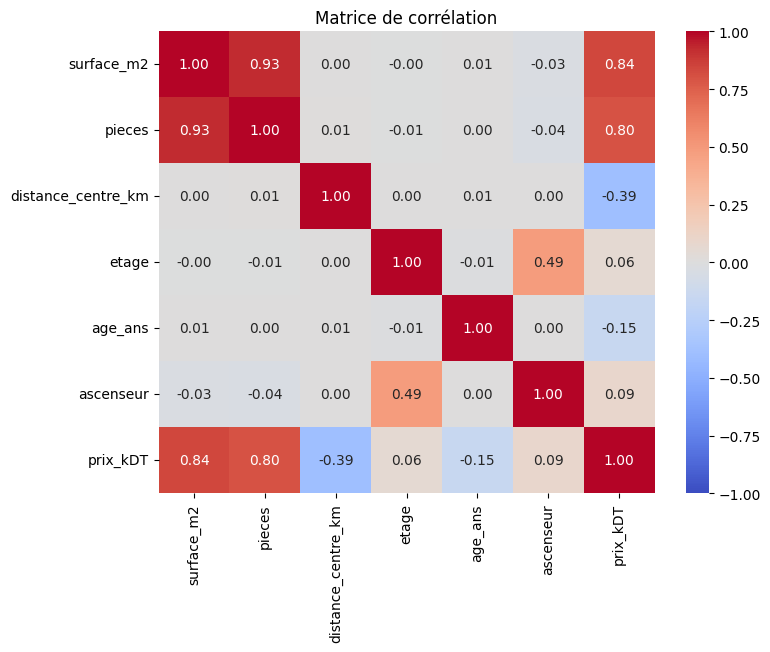

,prix_kDT
surface_m2,0.840450
pieces,0.804328
distance_centre_km,-0.393786
age_ans,-0.151164
ascenseur,0.089992
etage,0.055264


In [5]:
import seaborn as sns

corr = df.corr()

plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("Matrice de corrélation")
plt.show()

# Corrélation de chaque variable avec le prix, de la plus forte à la plus faible
corr["prix_kDT"].drop("prix_kDT").sort_values(key=abs, ascending=False)

**Séparation entrainement / test**

In [6]:
X = df.drop(columns="prix_kDT")
y = df["prix_kDT"].values

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=SEED)
print(f"Entraînement : {len(X_train)}  |  Test : {len(X_test)}")

resultats = []

Entraînement : 1200  |  Test : 300


**premier modèle KNN avec k=5**

In [7]:

modele = Pipeline([
    ("scaler", StandardScaler()),                    # Normalisation : mise sur la meme échelle
    ("knn", KNeighborsRegressor(n_neighbors=5))      # prix = moyenne des 5 voisins les plus proches
])

modele.fit(X_train, y_train)        # entraînement : le KNN mémorise les données
y_pred = modele.predict(X_test)     # prédiction sur le jeu de test

metriques("KNN K=5", y_test, y_pred)


--- KNN K=5 ---
MAE  =     23.9 kDT   erreur moyenne en valeur absolue
MSE  =      882       erreur quadratique moyenne (unité au carré, peu lisible)
RMSE =     29.7 kDT   racine de la MSE : pénalise davantage les grosses erreurs
R²   =    0.926       part de la variance des prix expliquée (1 = parfait, 0 = naïf)
MAPE =     12.5 %     erreur moyenne en pourcentage du prix réel


{'modèle': 'KNN K=5',
 'MAE': 23.9314,
 'RMSE': np.float64(29.70239777077489),
 'R²': 0.9259796875803714,
 'MAPE %': 12.496082185221303}

**trouver le meilleur K (validation croisée)**

In [8]:
cv = KFold(n_splits=5, shuffle=True, random_state=SEED)

recherche = GridSearchCV(
    Pipeline([("scaler", StandardScaler()), ("knn", KNeighborsRegressor())]),
    {
        "knn__n_neighbors": list(range(1, 41)),      # on teste K de 1 à 40
        "knn__weights": ["uniform", "distance"],     # distance : les voisins proches pèsent plus
        "knn__p": [1, 2],                            # 1 = Manhattan, 2 = euclidienne
    },
    cv=cv, scoring="neg_root_mean_squared_error", n_jobs=-1,
)
recherche.fit(X_train, y_train)

print("Meilleurs paramètres :", recherche.best_params_)

Meilleurs paramètres : {'knn__n_neighbors': 8, 'knn__p': 2, 'knn__weights': 'distance'}


**évaluer le modèle final**

In [9]:
modele_final = recherche.best_estimator_
y_pred_final = modele_final.predict(X_test)

metriques("KNN optimisé", y_test, y_pred_final)


--- KNN optimisé ---
MAE  =     23.4 kDT   erreur moyenne en valeur absolue
MSE  =      834       erreur quadratique moyenne (unité au carré, peu lisible)
RMSE =     28.9 kDT   racine de la MSE : pénalise davantage les grosses erreurs
R²   =    0.930       part de la variance des prix expliquée (1 = parfait, 0 = naïf)
MAPE =     12.3 %     erreur moyenne en pourcentage du prix réel


{'modèle': 'KNN optimisé',
 'MAE': 23.4246727710586,
 'RMSE': np.float64(28.876217297939778),
 'R²': 0.930040210067522,
 'MAPE %': 12.31156910946377}

**comparer les résultats avec ce qui est réél graphiquement**

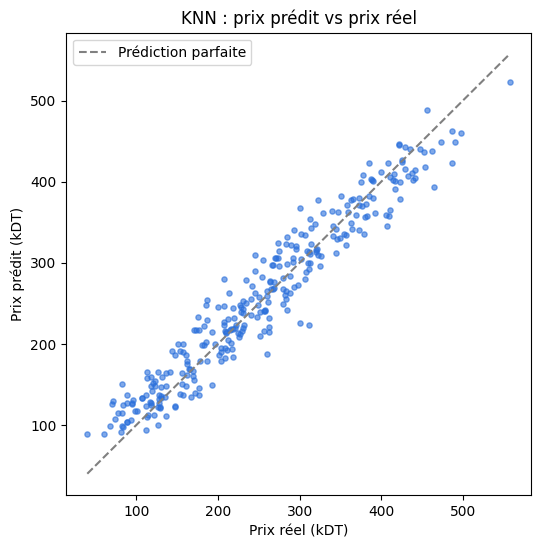

In [10]:
plt.figure(figsize=(6, 6))
plt.scatter(y_test, y_pred_final, s=14, alpha=0.6, color="#2a6fdb")
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, color="grey", ls="--", label="Prédiction parfaite")
plt.xlabel("Prix réel (kDT)")
plt.ylabel("Prix prédit (kDT)")
plt.title("KNN : prix prédit vs prix réel")
plt.legend()
plt.show()

**Prédiction d une nouvelle donnée**

In [11]:
nouveau = pd.DataFrame([{
    "surface_m2": 95, "pieces": 3, "distance_centre_km": 4.0,
    "etage": 2, "age_ans": 10, "ascenseur": 1,
}])

prix_estime = modele_final.predict(nouveau)[0]
print(f"Prix estimé : {prix_estime:.1f} kDT")

Prix estimé : 240.5 kDT


In [12]:
import ipywidgets as widgets
from IPython.display import display, clear_output

# Définition des widgets pour chaque caractéristique
surface_widget = widgets.IntSlider(value=95, min=30, max=220, step=1, description="Surface (m²)")
pieces_widget = widgets.IntSlider(value=3, min=1, max=7, step=1, description="Pièces")
distance_widget = widgets.FloatSlider(value=4.0, min=0.0, max=30.0, step=0.1, description="Dist. centre (km)")
etage_widget = widgets.IntSlider(value=2, min=0, max=10, step=1, description="Étage")
age_widget = widgets.IntSlider(value=10, min=0, max=50, step=1, description="Âge (années)")
ascenseur_widget = widgets.Dropdown(options=[("Oui", 1), ("Non", 0)], value=1, description="Ascenseur")

bouton_predire = widgets.Button(description="Estimer le prix", button_style="primary")
sortie = widgets.Output()

def calculer_estimation(b):
    with sortie:
        clear_output()
        # Création du DataFrame avec les valeurs saisies
        nouveau_df = pd.DataFrame([{
            "surface_m2": surface_widget.value,
            "pieces": pieces_widget.value,
            "distance_centre_km": distance_widget.value,
            "etage": etage_widget.value,
            "age_ans": age_widget.value,
            "ascenseur": ascenseur_widget.value
        }])

        # Prédiction
        prix_estime = modele_final.predict(nouveau_df)[0]

        print(f"\n🏠 Caractéristiques saisies :")
        print(f"   - Surface : {surface_widget.value} m² | Pièces : {pieces_widget.value} | Étage : {etage_widget.value}")
        print(f"   - Distance centre-ville : {distance_widget.value} km | Âge : {age_widget.value} ans | Ascenseur : {'Oui' if ascenseur_widget.value == 1 else 'Non'}")
        print(f"\n💰 PRIX ESTIMÉ : {prix_estime:.1f} kDT")

bouton_predire.on_click(calculer_estimation)

# Mise en page de l'interface
interface = widgets.VBox([
    widgets.HTML(value="<h4>Saisir les caractéristiques de l'appartement :</h4>"),
    surface_widget,
    pieces_widget,
    distance_widget,
    etage_widget,
    age_widget,
    ascenseur_widget,
    widgets.Label(value=""),
    bouton_predire,
    sortie
])

display(interface)

**métriques d'évaluation après prédiction**

In [20]:
erreurs = y_test - y_pred_final          # erreur = prix réel − prix prédit

mae  = np.mean(np.abs(erreurs))                                          # moyenne des erreurs en valeur absolue
mse  = np.mean(erreurs ** 2)                                             # moyenne des erreurs au carré
rmse = np.sqrt(mse)                                                      # racine de la MSE (revient en kDT)
r2   = 1 - np.sum(erreurs ** 2) / np.sum((y_test - y_test.mean()) ** 2)  # part de variance expliquée
mape = np.mean(np.abs(erreurs / y_test)) * 100                           # erreur moyenne en %


print("\nVérification avec scikit-learn :")
print(f"MAE  = {mean_absolute_error(y_test, y_pred_final):.1f}")
print(f"RMSE = {np.sqrt(mean_squared_error(y_test, y_pred_final)):.1f}")
print(f"R²   = {r2_score(y_test, y_pred_final):.3f}")
print(f"MAPE = {mean_absolute_percentage_error(y_test, y_pred_final) * 100:.1f} %")


Vérification avec scikit-learn :
MAE  = 23.4
RMSE = 28.9
R²   = 0.930
MAPE = 12.3 %


In [21]:
prix_moyen = y_test.mean()
print(f"Prix moyen d'un appartement : {prix_moyen:.0f} kDT")
print(f"Erreur moyenne (MAE)        : {mae:.0f} kDT, soit {mae / prix_moyen * 100:.0f} % du prix moyen")
print(f"Le modèle explique {r2 * 100:.0f} % des variations de prix (R²)\n")

if r2 >= 0.9:
    print("R² ≥ 0,9 : très bon modèle")
elif r2 >= 0.7:
    print("0,7 ≤ R² < 0,9 : bon modèle")
elif r2 >= 0.5:
    print("0,5 ≤ R² < 0,7 : modèle moyen")
else:
    print("R² < 0,5 : modèle faible")

Prix moyen d'un appartement : 253 kDT
Erreur moyenne (MAE)        : 23 kDT, soit 9 % du prix moyen
Le modèle explique 93 % des variations de prix (R²)

R² ≥ 0,9 : très bon modèle


**comparer k=5 et modèle optimisé**

In [15]:
comparaison = pd.DataFrame([
    {"modèle": "KNN K=5",
     "MAE": mean_absolute_error(y_test, y_pred),
     "RMSE": np.sqrt(mean_squared_error(y_test, y_pred)),
     "R²": r2_score(y_test, y_pred),
     "MAPE %": mean_absolute_percentage_error(y_test, y_pred) * 100},
    {"modèle": "KNN optimisé", "MAE": mae, "RMSE": rmse, "R²": r2, "MAPE %": mape},
]).round(3)
comparaison

,modèle,MAE,RMSE,R²,MAPE %
0,KNN K=5,23.931,29.702,0.926,12.496
1,KNN optimisé,23.425,28.876,0.930,12.312


In [16]:
# Modèle K=5 : erreur sur l'entraînement vs sur le test
rmse_train_k5 = np.sqrt(mean_squared_error(y_train, modele.predict(X_train)))
rmse_test_k5  = np.sqrt(mean_squared_error(y_test, y_pred))
print(f"KNN K=5      → RMSE entraînement = {rmse_train_k5:.1f}   RMSE test = {rmse_test_k5:.1f}")

# Modèle optimisé : erreur en validation croisée vs sur le test
# (pondéré par la distance, il retrouve exactement les prix d'entraînement :
#  son erreur d'entraînement vaut 0 et ne veut rien dire, on utilise donc la validation croisée)
rmse_cv = -recherche.best_score_
print(f"KNN optimisé → RMSE validation    = {rmse_cv:.1f}   RMSE test = {rmse:.1f}")

print("\nÉcart faible entre les deux colonnes : pas de surapprentissage, le modèle généralise bien.")

KNN K=5      → RMSE entraînement = 27.3   RMSE test = 29.7
KNN optimisé → RMSE validation    = 33.1   RMSE test = 28.9

Écart faible entre les deux colonnes : pas de surapprentissage, le modèle généralise bien.


**courbe de l'erreur selon K **

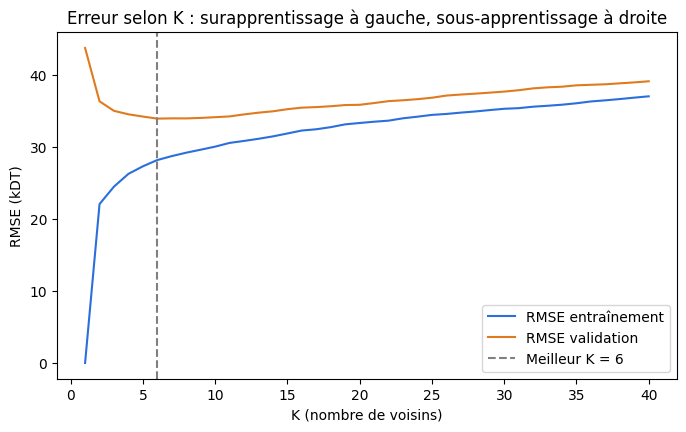

In [17]:
valeurs_k = list(range(1, 41))
rmse_train, rmse_val = [], []
for k in valeurs_k:
    m = Pipeline([("scaler", StandardScaler()),
                  ("knn", KNeighborsRegressor(n_neighbors=k))]).fit(X_train, y_train)
    rmse_train.append(np.sqrt(mean_squared_error(y_train, m.predict(X_train))))
    rmse_val.append(-cross_val_score(m, X_train, y_train, cv=cv,
                                     scoring="neg_root_mean_squared_error").mean())

k_best = valeurs_k[int(np.argmin(rmse_val))]

plt.figure(figsize=(8, 4.5))
plt.plot(valeurs_k, rmse_train, color="#2a6fdb", label="RMSE entraînement")
plt.plot(valeurs_k, rmse_val, color="#e07a1f", label="RMSE validation")
plt.axvline(k_best, color="grey", ls="--", label=f"Meilleur K = {k_best}")
plt.xlabel("K (nombre de voisins)")
plt.ylabel("RMSE (kDT)")
plt.title("Erreur selon K : surapprentissage à gauche, sous-apprentissage à droite")
plt.legend()
plt.show()

**analyse des erreurs résidus**

Erreur moyenne      : -4.1 kDT (proche de 0 = pas de biais)
50 % des erreurs    < 19.8 kDT
90 % des erreurs    < 45.6 kDT


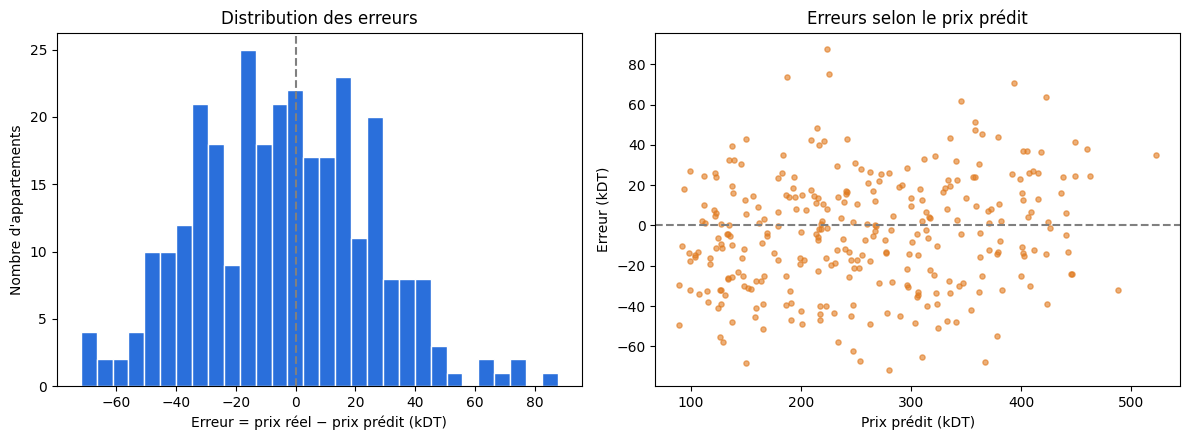

In [18]:
print(f"Erreur moyenne      : {erreurs.mean():+.1f} kDT (proche de 0 = pas de biais)")
print(f"50 % des erreurs    < {np.median(np.abs(erreurs)):.1f} kDT")
print(f"90 % des erreurs    < {np.percentile(np.abs(erreurs), 90):.1f} kDT")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
axes[0].hist(erreurs, bins=30, color="#2a6fdb", edgecolor="white")
axes[0].axvline(0, color="grey", ls="--")
axes[0].set_xlabel("Erreur = prix réel − prix prédit (kDT)")
axes[0].set_ylabel("Nombre d'appartements")
axes[0].set_title("Distribution des erreurs")
axes[1].scatter(y_pred_final, erreurs, s=14, alpha=0.6, color="#e07a1f")
axes[1].axhline(0, color="grey", ls="--")
axes[1].set_xlabel("Prix prédit (kDT)")
axes[1].set_ylabel("Erreur (kDT)")
axes[1].set_title("Erreurs selon le prix prédit")
plt.tight_layout()
plt.show()

**les 5 plus grosses erreurs**

In [19]:
analyse = X_test.copy()
analyse["prix_reel"] = y_test.round(1)
analyse["prix_predit"] = y_pred_final.round(1)
analyse["erreur"] = erreurs.round(1)
analyse.reindex(analyse["erreur"].abs().sort_values(ascending=False).index).head()

,surface_m2,pieces,distance_centre_km,etage,age_ans,ascenseur,prix_reel,prix_predit,erreur
107,82.0,3,0.8,7,24.0,1,311.2,223.6,87.6
32,92.0,3,5.1,6,3.0,1,300.2,225.3,74.9
1440,75.0,2,5.8,1,17.0,1,260.6,187.1,73.5
626,181.0,6,15.1,4,19.0,1,207.8,279.6,-71.8
1259,219.0,7,3.9,3,42.0,0,464.4,393.6,70.8
